[2026-04-08 15:50:13] === 3銘柄をランダムに選択 ===
選ばれた3銘柄:
 - USDT
 - USDC
 - AVAX
[2026-04-08 15:50:13] Fetching USDT ...
[2026-04-08 15:50:13] [USDT] rows=2161
[2026-04-08 15:50:14] Fetching USDC ...
[2026-04-08 15:50:14] [USDC] rows=2162
[2026-04-08 15:50:15] Fetching AVAX ...
[2026-04-08 15:50:15] [AVAX] rows=2162
[2026-04-08 15:50:15] === 価格プロット ===


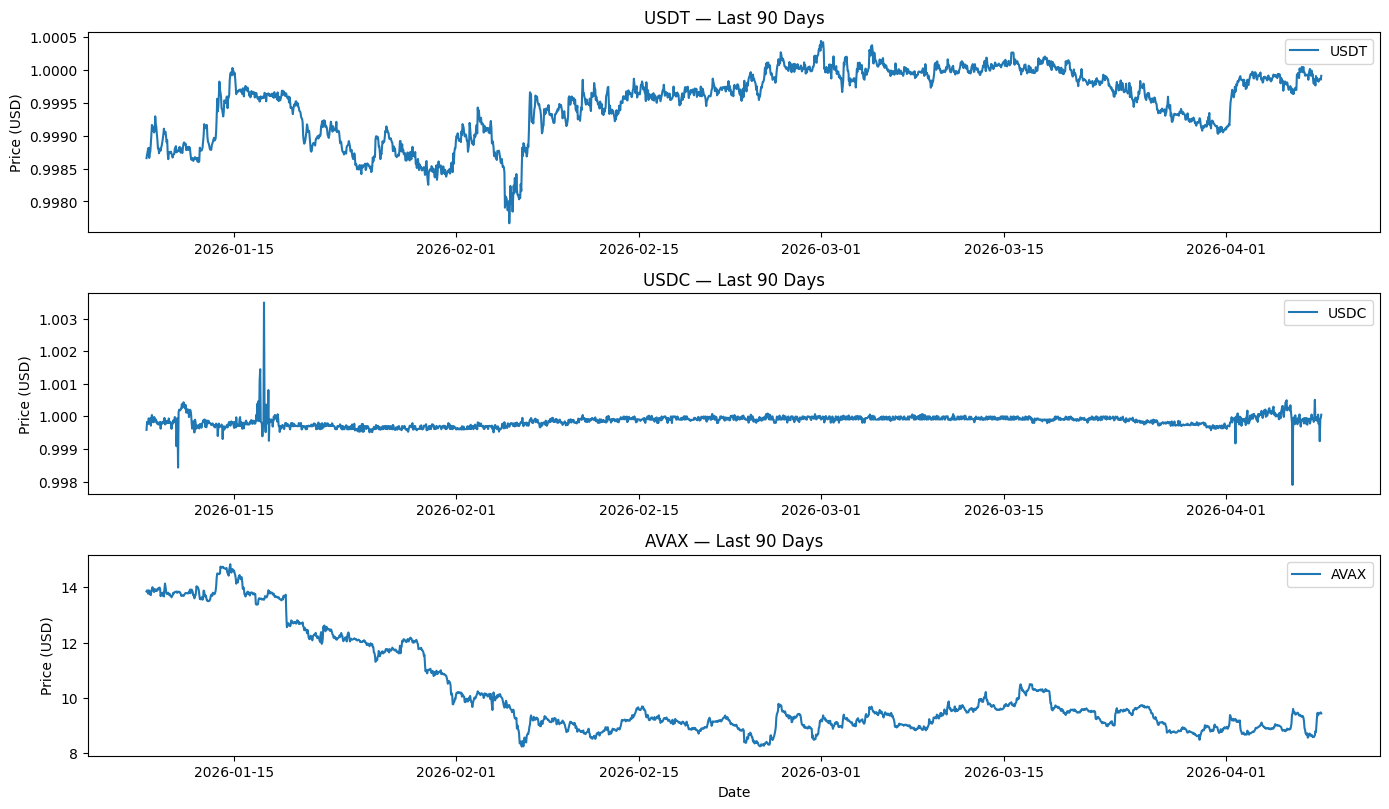

[2026-04-08 15:50:17] === 価格そのものに AR を適用（in-sample） ===
[2026-04-08 15:50:17] [USDT] Fitting AR(5) on price (length=2161)
[2026-04-08 15:50:17] [USDT] in-sample (last 50 pts) MSE=3.673910e-09, RMSE=6.061279e-05


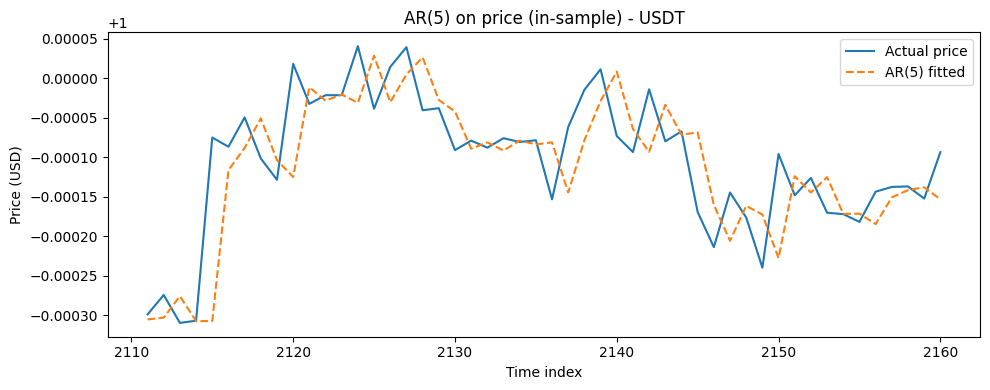

[2026-04-08 15:50:18] [USDC] Fitting AR(5) on price (length=2162)
[2026-04-08 15:50:18] [USDC] in-sample (last 50 pts) MSE=2.884519e-08, RMSE=1.698387e-04


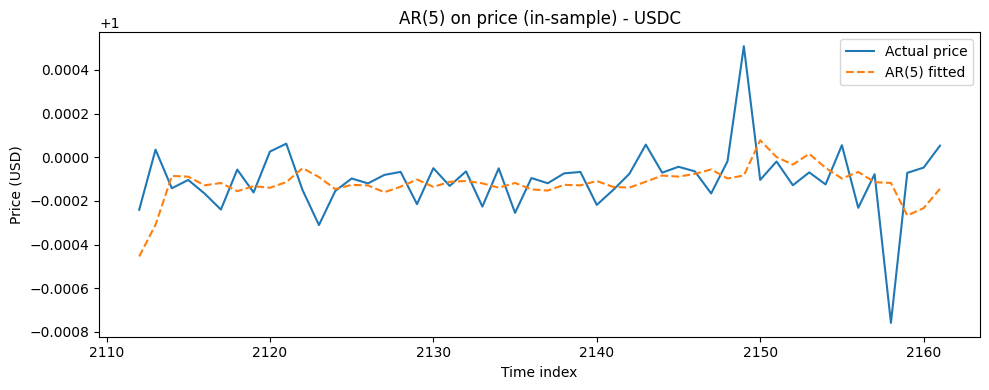

[2026-04-08 15:50:19] [AVAX] Fitting AR(5) on price (length=2162)
[2026-04-08 15:50:19] [AVAX] in-sample (last 50 pts) MSE=7.189979e-03, RMSE=8.479375e-02


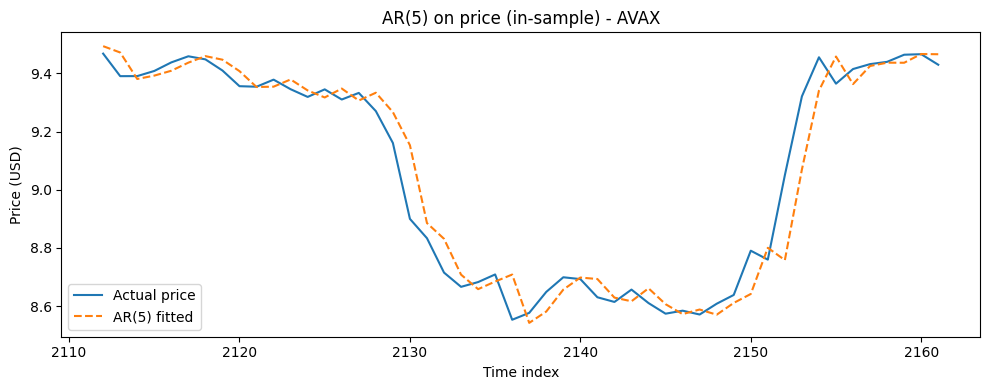

[2026-04-08 15:50:20] === 変化点検知（log return） ===
[2026-04-08 15:52:29] [USDT] change points (raw): [2160]
[2026-04-08 15:52:29] [USDT] change points (valid): []


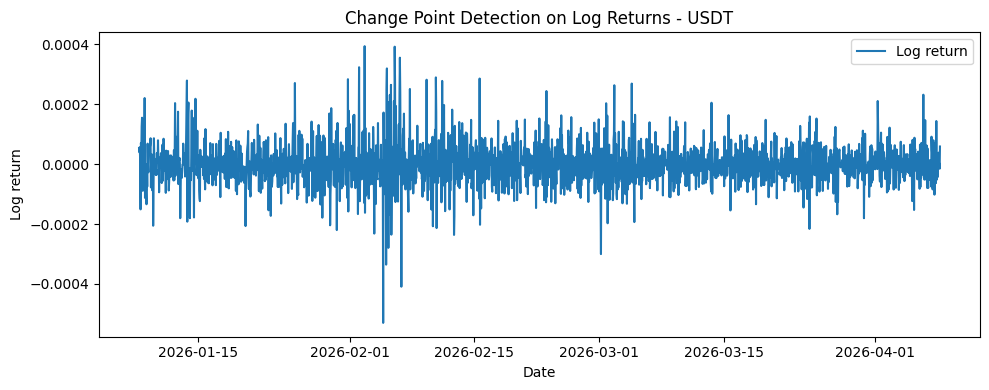


=== USDT の変化点候補 ===
変化点は検出されませんでした。


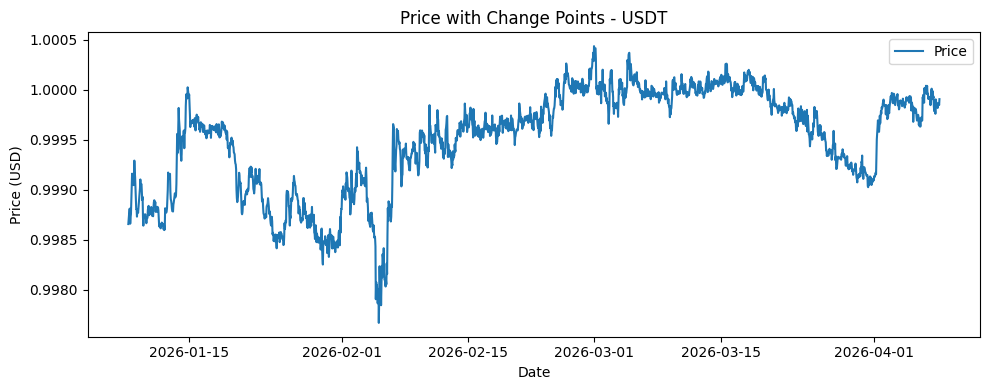

[2026-04-08 15:54:27] [USDC] change points (raw): [255, 1995, 2161]
[2026-04-08 15:54:27] [USDC] change points (valid): [255, 1995]


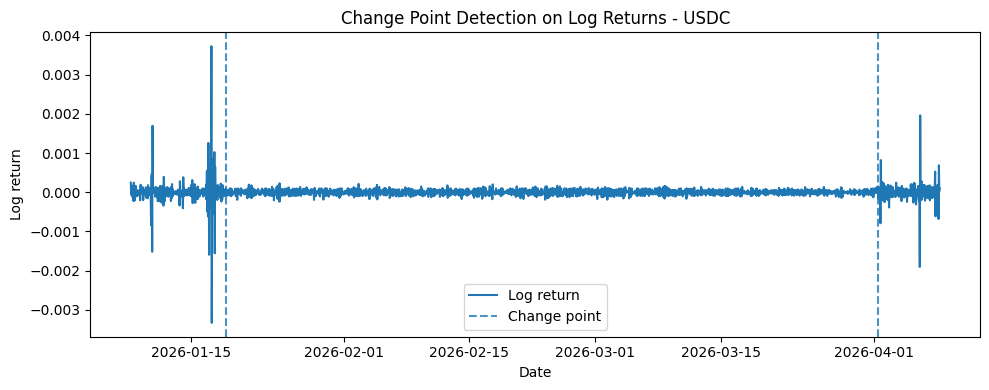


=== USDC の変化点候補 ===
1. 2026-01-18 23:02:36.791000 付近, 価格=0.999797
2. 2026-04-01 10:01:21.988000 付近, 価格=0.999976


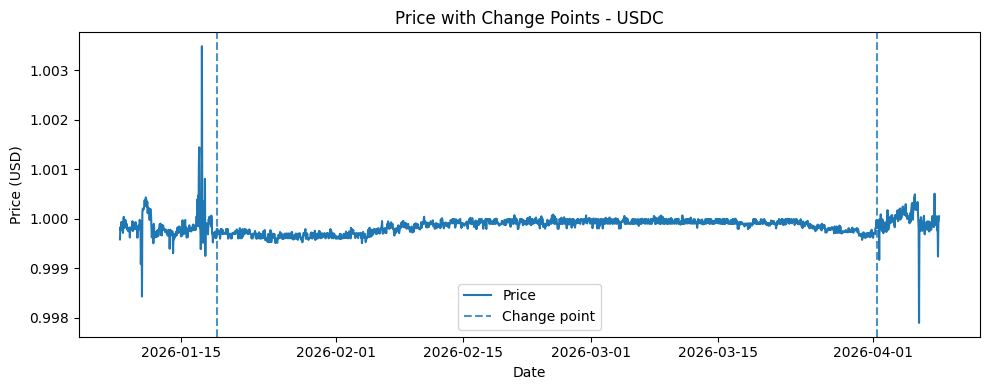

[2026-04-08 15:56:40] [AVAX] change points (raw): [2161]
[2026-04-08 15:56:40] [AVAX] change points (valid): []


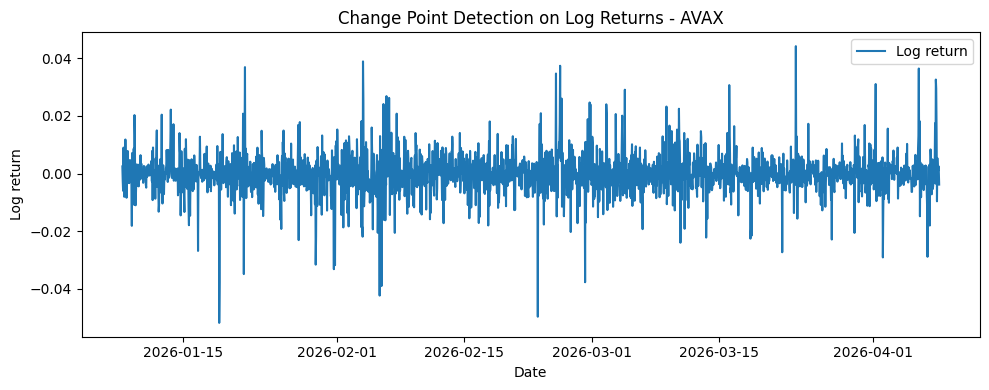


=== AVAX の変化点候補 ===
変化点は検出されませんでした。


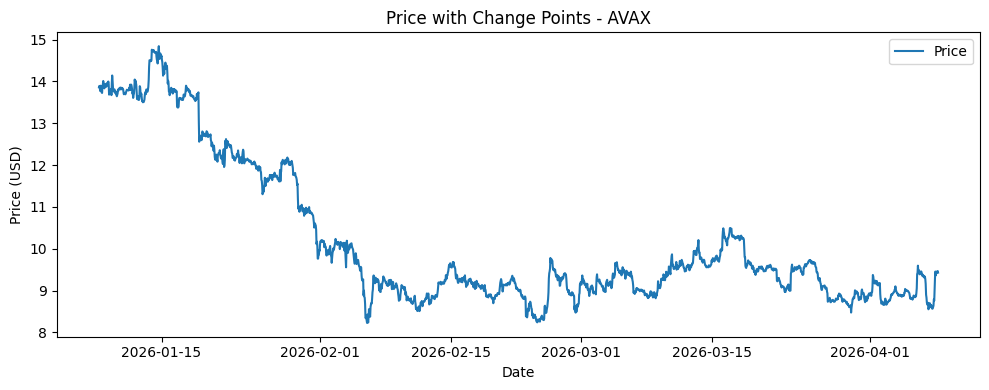

In [1]:
import random
import time
from datetime import datetime

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
import ruptures as rpt


# ------------------------
# 設定
# ------------------------
COINS_POOL = [
    ("bitcoin", "BTC"),
    ("ethereum", "ETH"),
    ("tether", "USDT"),
    ("binancecoin", "BNB"),
    ("solana", "SOL"),
    ("ripple", "XRP"),
    ("usd-coin", "USDC"),
    ("cardano", "ADA"),
    ("dogecoin", "DOGE"),
    ("avalanche-2", "AVAX"),
]

VS = "usd"
DAYS = 90
BASE = "https://api.coingecko.com/api/v3/coins/{id}/market_chart"

AR_LAGS = 5
CHANGE_MODEL = "rbf"   # "l2", "rbf" など
CHANGE_PEN = 10        # 小さいほど変化点が増えやすい
TAIL_POINTS = 50       # AR表示の末尾点数

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})


def log(msg: str):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")


# ------------------------
# データ取得
# ------------------------
def fetch_market_chart(coin_id, days=90, vs="usd"):
    """
    CoinGeckoから指定銘柄の価格系列を取得
    戻り値: timestamp, price を持つ DataFrame
    """
    url = BASE.format(id=coin_id)
    params = {"vs_currency": vs, "days": days}

    r = session.get(url, params=params, timeout=30)
    r.raise_for_status()

    data = r.json()
    df = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna(subset=["timestamp", "price"]).sort_values("timestamp").reset_index(drop=True)
    return df


# ------------------------
# AR を価格そのものに適用（in-sample）
# ------------------------
def apply_ar_price_in_sample(df: pd.DataFrame, symbol: str, lags: int = 5, tail_points: int = 50):
    """
    価格そのものに AR(lags) を当てて、
    fitted values と実データを末尾区間で比較する
    """
    series = pd.Series(df["price"].values.astype(float))

    if len(series) <= lags + 5:
        log(f"[{symbol}] データが短すぎるため AR をスキップします")
        return None, None

    log(f"[{symbol}] Fitting AR({lags}) on price (length={len(series)})")
    model = AutoReg(series, lags=lags, old_names=False)
    res = model.fit()

    fitted = res.fittedvalues
    actual = series[lags:]
    idx = np.arange(lags, len(series))

    tail = min(tail_points, len(idx))
    idx_tail = idx[-tail:]
    actual_tail = actual.iloc[-tail:]
    fitted_tail = fitted.iloc[-tail:]

    min_len = min(len(idx_tail), len(actual_tail), len(fitted_tail))
    idx_tail = idx_tail[-min_len:]
    actual_tail = actual_tail.iloc[-min_len:]
    fitted_tail = fitted_tail.iloc[-min_len:]

    mse = ((actual_tail.values - fitted_tail.values) ** 2).mean()
    rmse = np.sqrt(mse)

    log(f"[{symbol}] in-sample (last {min_len} pts) MSE={mse:.6e}, RMSE={rmse:.6e}")

    plt.figure(figsize=(10, 4))
    plt.plot(idx_tail, actual_tail.values, label="Actual price")
    plt.plot(idx_tail, fitted_tail.values, "--", label=f"AR({lags}) fitted")
    plt.title(f"AR({lags}) on price (in-sample) - {symbol}")
    plt.xlabel("Time index")
    plt.ylabel(f"Price ({VS.upper()})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mse, rmse


# ------------------------
# 変化点検知
# ------------------------
def detect_change_points(df: pd.DataFrame, symbol: str, model_name="rbf", pen=10):
    """
    価格系列 -> log return に変換し、変化点検知
    戻り値:
      bkps          : returns 上の変化点インデックス（終端含む）
      valid_bkps    : 終端を除いた変化点
      returns       : log return 配列
      return_times  : returns に対応する timestamp
    """
    prices = df["price"].values.astype(float)

    if len(prices) < 10:
        log(f"[{symbol}] データが短すぎるため変化点検知をスキップします")
        return [], [], np.array([]), pd.Series(dtype="datetime64[ns]")

    returns = np.diff(np.log(prices))
    return_times = df["timestamp"].iloc[1:].reset_index(drop=True)

    signal = returns.reshape(-1, 1)

    algo = rpt.Pelt(model=model_name).fit(signal)
    bkps = algo.predict(pen=pen)

    # 終端（len(returns)）を除外
    valid_bkps = [b for b in bkps if b < len(returns)]

    log(f"[{symbol}] change points (raw): {bkps}")
    log(f"[{symbol}] change points (valid): {valid_bkps}")

    # リターン上に描画
    plt.figure(figsize=(10, 4))
    plt.plot(return_times, returns, label="Log return")

    for i, b in enumerate(valid_bkps):
        plt.axvline(return_times.iloc[b], linestyle="--", alpha=0.8,
                    label="Change point" if i == 0 else None)

    plt.title(f"Change Point Detection on Log Returns - {symbol}")
    plt.xlabel("Date")
    plt.ylabel("Log return")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return bkps, valid_bkps, returns, return_times


# ------------------------
# 価格系列の上に変化点を重ねる
# ------------------------
def plot_price_with_change_points(df: pd.DataFrame, symbol: str, valid_bkps):
    """
    価格系列のグラフ上に変化点を表示
    valid_bkps は returns 側の index を想定
    """
    plt.figure(figsize=(10, 4))
    plt.plot(df["timestamp"], df["price"], label="Price")

    for i, b in enumerate(valid_bkps):
        # returns[b] は df timestamp の b+1 に対応
        if b + 1 < len(df):
            cp_time = df["timestamp"].iloc[b + 1]
            plt.axvline(cp_time, linestyle="--", alpha=0.8,
                        label="Change point" if i == 0 else None)

    plt.title(f"Price with Change Points - {symbol}")
    plt.xlabel("Date")
    plt.ylabel(f"Price ({VS.upper()})")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------
# 要約表示
# ------------------------
def summarize_change_points(df: pd.DataFrame, symbol: str, valid_bkps):
    """
    変化点の日時と価格を表示
    """
    print(f"\n=== {symbol} の変化点候補 ===")
    if not valid_bkps:
        print("変化点は検出されませんでした。")
        return

    for i, b in enumerate(valid_bkps, start=1):
        if b + 1 < len(df):
            t = df["timestamp"].iloc[b + 1]
            p = df["price"].iloc[b + 1]
            print(f"{i}. {t} 付近, 価格={p:.6f}")


# ------------------------
# 全体価格プロット
# ------------------------
def plot_selected_prices(dfs: dict):
    plt.figure(figsize=(14, 8))

    for idx, (symbol, df) in enumerate(dfs.items(), start=1):
        plt.subplot(len(dfs), 1, idx)
        plt.plot(df["timestamp"], df["price"], label=symbol)
        plt.title(f"{symbol} — Last {DAYS} Days")
        plt.ylabel(f"Price ({VS.upper()})")
        plt.legend()
        plt.tight_layout()

    plt.xlabel("Date")
    plt.show()


# ------------------------
# メイン処理
# ------------------------
def main():
    log("=== 3銘柄をランダムに選択 ===")
    selected = random.sample(COINS_POOL, 3)

    print("選ばれた3銘柄:")
    for _, sym in selected:
        print(" -", sym)

    dfs = {}

    # データ取得
    for coin_id, symbol in selected:
        try:
            log(f"Fetching {symbol} ...")
            df = fetch_market_chart(coin_id, DAYS, VS)
            dfs[symbol] = df
            log(f"[{symbol}] rows={len(df)}")
            time.sleep(0.5)
        except Exception as e:
            log(f"[{symbol}] 取得失敗: {e}")

    if not dfs:
        log("取得できた銘柄がありません。終了します。")
        return

    # 価格プロット
    log("=== 価格プロット ===")
    plot_selected_prices(dfs)

    # AR
    log("=== 価格そのものに AR を適用（in-sample） ===")
    for symbol, df in dfs.items():
        try:
            apply_ar_price_in_sample(df, symbol, lags=AR_LAGS, tail_points=TAIL_POINTS)
            time.sleep(0.5)
        except Exception as e:
            log(f"[{symbol}] AR失敗: {e}")

    # 変化点検知
    log("=== 変化点検知（log return） ===")
    for symbol, df in dfs.items():
        try:
            bkps, valid_bkps, returns, return_times = detect_change_points(
                df, symbol, model_name=CHANGE_MODEL, pen=CHANGE_PEN
            )
            summarize_change_points(df, symbol, valid_bkps)
            plot_price_with_change_points(df, symbol, valid_bkps)
            time.sleep(0.5)
        except Exception as e:
            log(f"[{symbol}] 変化点検知失敗: {e}")


if __name__ == "__main__":
    main()